<center><h1>In the name of Allah</h1></center>

Name:

Student Number:

In this notebook, you will explore adversarial attacks and training methods in deep learning. First, you will train a simple model, ResNet18, on the CIFAR-10 dataset. Next, you will learn about two different adversarial attacks: FGSM (Fast Gradient Sign Method) and PGD (Projected Gradient Descent). To enhance your understanding, you will implement the PGD attack from scratch, while the FGSM attack will be implemented using a library. After this, you will use the FGSM attack to generate adversarial examples and then perform adversarial training on the model using the CIFAR-10 dataset. Finally, you will compare the performance and robustness of the adversarially trained model with the original model.

Good luck!

## outline
- Train Resnet on CIFAR10
- FGSM Attack using torchattacks
- PGD Attack from scratch
- Visualization
- Adversarial Training


In [ ]:
!pip install torchattacks

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 10.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.9/143.9 kB 14.1 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.w

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
from torch.autograd import Variable
from tqdm import tqdm

In [ ]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


## Train Resnet on CIFAR10 (15 pts)

In [ ]:
# Prepare Cifar10 data
batch_size = 128
transform = transforms.Compose([transforms.ToTensor(),])

##############################################################################
# Prepare training and test datasets and dataloaders                         #
##############################################################################

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
################################ End #########################################


100%|██████████| 170498071/170498071 [00:02<00:00, 78641197.51it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [ ]:
model_name = "/content/drive/MyDrive/Colab_Notebooks/DL/resnet18_cifar10_model_pretrained.pth"
adv_model_name = "/content/drive/MyDrive/Colab_Notebooks/DL/resnet18_cifar10_model_pretrained_advtrained.pth"
model_PATH = f"{model_name}"
adv_model_PATH = f"{adv_model_name}"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# model architecture
class resnet(nn.Module):
  def __init__(self, num_cls):
    super().__init__()
    self.conv = nn.Sequential(*list(resnet18(weights=None).children())[:-2])
    self.fc = nn.Linear(512, num_cls)

  def forward(self, x):
    x = self.conv(x)
    x = torch.flatten(x, start_dim=1)
    logits = self.fc(x)
    return logits

##############################################################################
# Initialize model and move to device                                        #
##############################################################################
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = resnet(num_cls=len(classes)).to(device)
################################ End #########################################

In [ ]:
learning_rate = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
epochs = 100

In [ ]:
##############################################################################
# Implement train loop and log training loss after each epoch                #
##############################################################################
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in tqdm(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(trainloader)}")
################################ End #########################################

  0%|          | 0/391 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
100%|██████████| 391/391 [00:18<00:00, 21.62it/s]


Epoch 1, Loss: 1.5427194617288498


100%|██████████| 391/391 [00:16<00:00, 23.10it/s]


Epoch 2, Loss: 1.1301602727311957


100%|██████████| 391/391 [00:19<00:00, 20.43it/s]


...

Epoch 98, Loss: 6.680189243504157e-05


100%|██████████| 391/391 [00:18<00:00, 21.56it/s]


Epoch 99, Loss: 6.063358700431562e-05


100%|██████████| 391/391 [00:17<00:00, 22.04it/s]

Epoch 100, Loss: 7.574403343417025e-05


In [ ]:
##############################################################################
# Evaluate the trained model on test set and print test accuracy             #
##############################################################################

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for idx, (inputs, labels) in enumerate(testloader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        if idx % 100 == 0:
            print(f"Test Accuracy for batch index = {idx}: {100 * correct /labels.size(0)}%")
print(f"Test Accuracy: {100 * correct / total}%")

################################ End #########################################

Test Accuracy for batch index = 0: 79.6875%
Test Accuracy: 75.8%


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


In [ ]:
# Save model
model.eval()
torch.save(model.state_dict(), model_PATH)

## FGSM Attack using torchattacks (10 pts)

In this section you should run FGSM attack using torchattacks library (https://adversarial-attacks-pytorch.readthedocs.io/en/latest/index.html).

Run the attack for $\epsilon \in \{\frac{1}{255}, \frac{4}{255}, \frac{8}{255},\}$ report the performance of the model on untargeted FGSM attack on the test data.

In [ ]:
import torchattacks.attacks as attacks

In [ ]:
# Define a function to evaluate the model's performance on adversarial examples
def evaluate_adversarial_performance(model, testloader, attack):
    model.eval()
    correct = 0
    total = 0
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        inputs.requires_grad = True
        adv_inputs = attack(inputs, labels)
        outputs = model(adv_inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

# Load the pretrained model
model = resnet(num_cls=len(classes)).to(device)
model.load_state_dict(torch.load(model_PATH))
model.eval()

# Define epsilon values
epsilons = [1/255, 4/255, 8/255]


In [ ]:
##############################################################################
# run untargeted FGSM attack for epsilon = 1/255 and report its accuracy     #
##############################################################################
eps = epsilons[0]
attack = attacks.fgsm.FGSM(model, eps=eps)
accuracy = evaluate_adversarial_performance(model, testloader, attack)
print(f"Test Accuracy under FGSM attack with epsilon={eps*255:.0f}/255: {accuracy:.2f}%")

################################ End #########################################

Test Accuracy under FGSM attack with epsilon=1/255: 53.55%


/usr/local/lib/python3.10/dist-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [ ]:
##############################################################################
# run untargeted FGSM attack for epsilon = 4/255 and report its accuracy     #
##############################################################################
eps = epsilons[1]
attack = attacks.fgsm.FGSM(model, eps=eps)
accuracy = evaluate_adversarial_performance(model, testloader, attack)
print(f"Test Accuracy under FGSM attack with epsilon={eps*255:.0f}/255: {accuracy:.2f}%")

################################ End #########################################

Test Accuracy under FGSM attack with epsilon=4/255: 24.01%


In [ ]:
##############################################################################
# run untargeted FGSM attack for epsilon = 8/255 and report its accuracy     #
##############################################################################
eps = epsilons[2]
attack = attacks.fgsm.FGSM(model, eps=eps)
accuracy = evaluate_adversarial_performance(model, testloader, attack)
print(f"Test Accuracy under FGSM attack with epsilon={eps*255:.0f}/255: {accuracy:.2f}%")
################################ End #########################################

Test Accuracy under FGSM attack with epsilon=8/255: 11.85%


## PGD Attack from scratch (30 pts)

In this section you should implement PGD attack from scratch.

In [ ]:
class LinfPGDAttack(object):

    def __init__(self, model, epsilon = 8/255, k = 2, alpha = 2/255):
        self.model = model
        self.epsilon = epsilon
        self.steps = k
        self.alpha = alpha

    def __call__(self, image, label):

        image = image.to(device)
        label = label.to(device)
        out = self.model(image)
        _, pred = torch.max(out, 1)

        perturbed_image = image.clone()
        perturbed_image.to(device)
        if pred.item() == label.item():
            ##############################################################################
            # Implement a k step PGD attack of size alpha                                #
            # while always staying within epsilon distance from the initial point        #
            # Use cross entropy loss                                                     #
            ##############################################################################

            for _ in range(self.steps):
              perturbed_image.requires_grad = True
              out = self.model(perturbed_image)
              loss = F.cross_entropy(out, label)
              self.model.zero_grad()
              loss.backward()

              # Gradient ascent step
              perturbed_image = perturbed_image + self.alpha * perturbed_image.grad.sign()

              # Ensure perturbations are within epsilon-ball
              perturbation = torch.clamp(perturbed_image - image, min=-self.epsilon, max=self.epsilon)
              perturbed_image = torch.clamp(image + perturbation, min=0, max=1.0).detach()

            ################################ End #########################################

        return perturbed_image

In [ ]:
##############################################################################
# Evaluate PGD attack on the trained model with k=2,4,8                      #
##############################################################################

k_list = [2,4,8]

##############################################################################

# Your code goes here
model = resnet(num_cls=len(classes)).to(device)
model.load_state_dict(torch.load(model_PATH))
model.eval()
accuracies = {}
for k in k_list:
  attack = LinfPGDAttack(model, k=k)
  correct = 0
  total = 0
  pbar = tqdm(enumerate(testloader))
  for batch_idx, (images, labels) in pbar:
    images, labels = images.to(device), labels.to(device)
    perturbed_images = torch.stack([attack(torch.unsqueeze(image,0), torch.unsqueeze(label,0)).squeeze() for image, label in zip(images, labels)])
    outputs = model(perturbed_images)
    _, predicted = torch.max(outputs.data, 1)
    total_now = labels.size(0)
    correct_now = (predicted == labels).sum().item()
    accuracy_now = 100 * correct_now / total_now
    accuracies[k] = accuracy_now
    pbar.set_description(f'Accuracy for batch {batch_idx} : {accuracy_now:.2f}%', refresh=True)
    correct += correct_now
    total += total_now

  accuracy = 100 * correct / total
  accuracies[k] = accuracy
  print(f'\nAccuracy under PGD attack with k={k}: {accuracy:.2f}%')

################################ End #########################################

Accuracy for batch 78 : 6.25%: : 79it [02:32,  1.92s/it]


Accuracy under PGD attack with k=2: 17.07%



Accuracy for batch 78 : 0.00%: : 79it [04:23,  3.34s/it]


Accuracy under PGD attack with k=4: 2.98%



Accuracy for batch 78 : 0.00%: : 79it [08:17,  6.30s/it]


Accuracy under PGD attack with k=8: 0.65%


## Visualization (10 pts)

Implement a function to plot the original image, the perturbed imaged and their predicted labels by the model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import random

In [ ]:
##############################################################################
# Implement the function described                                           #
##############################################################################

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')


def plot_images(orig_image, pert_image, orig_label, pert_label, attack_name):
    plt.figure(figsize=(5, 2))
    plt.subplot(1, 2, 1)
    imshow(orig_image.cpu().squeeze())
    plt.title(f'Original: {classes[orig_label]}')
    plt.subplot(1, 2, 2)
    imshow(pert_image.cpu().squeeze())
    plt.title(f'{attack_name} Perturbed: {classes[pert_label]}')
    plt.show()

################################ End #########################################

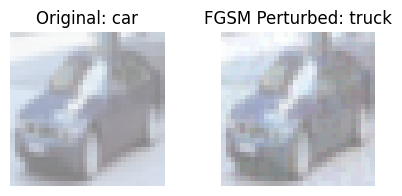

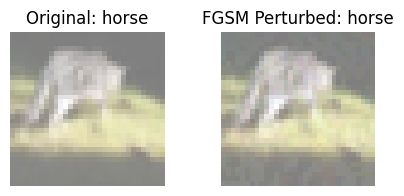

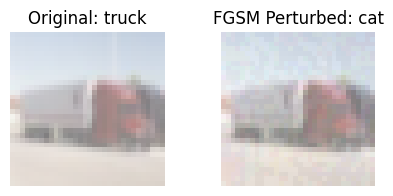

In [ ]:
##############################################################################
# Choose 3 random images from testset and run FGSM attack and visualize      #
##############################################################################

random_indices = random.sample(range(len(testset)), 3)
test_images = [testset[i][0] for i in random_indices]
test_labels = [testset[i][1] for i in random_indices]

# FGSM attack parameters
eps = 8/255
fgsm_attack = attacks.fgsm.FGSM(model, eps=eps)

# Visualize the results for FGSM attack
for i, (img, lbl) in enumerate(zip(test_images, test_labels)):
    img = img.unsqueeze(0).to(device)
    lbl = torch.tensor([lbl]).to(device)

    # Generate adversarial example
    adv_img = fgsm_attack(img, lbl)

    # Get model predictions
    orig_pred = model(img).argmax(1).item()
    adv_pred = model(adv_img).argmax(1).item()

    # Plot images
    plot_images(img.squeeze(), adv_img.squeeze(), orig_pred, adv_pred, "FGSM")





################################ End #########################################

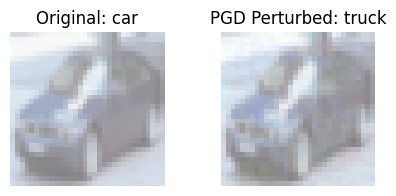

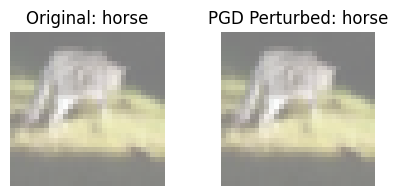

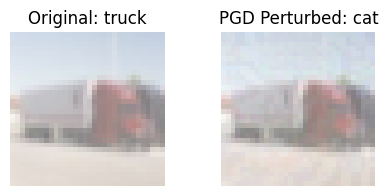

In [ ]:
##############################################################################
# Choose 3 random images from testset and run PGD attack and visualize      #
##############################################################################

k = 8
alpha = 2/255
pgd_attack = LinfPGDAttack(model, epsilon=8/255, k=k, alpha=alpha)

# Visualize the results for PGD attack
for i, (img, lbl) in enumerate(zip(test_images, test_labels)):
    img = img.unsqueeze(0).to(device)
    lbl = torch.tensor([lbl]).to(device)

    # Generate adversarial example
    adv_img = pgd_attack(img, lbl)

    # Get model predictions
    orig_pred = model(img).argmax(1).item()
    adv_pred = model(adv_img).argmax(1).item()

    # Plot images
    plot_images(img.squeeze(), adv_img.squeeze(), orig_pred, adv_pred, "PGD")

################################ End #########################################

## Adversarial Training (35 pts)

In this section you are going to adversarially train your model and see the results.

In [ ]:
##############################################################################
# Load a new resnet model for adversarial training                           #
# Train the model on perturbed images from                                   #
# untargeted FGSM attack with epsilon = 8/255 on train dataset               #
# Also use the following setup for training the model                        #
##############################################################################

adv_model = resnet(num_cls=len(classes)).to(device)# Your code goes here
adv_model.to(device)

learning_rate = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(adv_model.parameters(), lr=learning_rate, momentum=0.9)
epochs = 100


# Your code goes here

# FGSM attack parameters
eps = 8/255
fgsm_attack = attacks.fgsm.FGSM(adv_model, eps=eps)

# Adversarial training loop
for epoch in range(epochs):
    adv_model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        # Generate adversarial examples
        adv_images = fgsm_attack(images, labels)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = adv_model(adv_images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(trainloader):.4f}')

################################ End #########################################

Epoch [1/100], Loss: 2.1162
Epoch [2/100], Loss: 1.9846
Epoch [3/100], Loss: 1.9239
Epoch [4/100], Loss: 1.8854
Epoch [5/100], Loss: 1.8422
Epoch [6/100], Loss: 1.8099
Epoch [7/100], Loss: 1.7699
Epoch [8/100], Loss: 1.7371
Epoch [9/100], Loss: 1.7051
Epoch [10/100], Loss: 1.6703
Epoch [11/100], Loss: 1.6385
Epoch [12/100], Loss: 1.5998
Epoch [13/100], Loss: 1.5648
Epoch [14/100], Loss: 1.5249
Epoch [15/100], Loss: 1.4933
Epoch [16/100], Loss: 1.4517
Epoch [17/100], Loss: 1.4089
Epoch [18/100], Loss: 1.3683
Epoch [19/100], Loss: 1.3285
Epoch [20/100], Loss: 1.2901
Epoch [21/100], Loss: 1.2467
Epoch [22/100], Loss: 1.2093
Epoch [23/100], Loss: 1.1751
Epoch [24/100], Loss: 1.1323
Epoch [25/100], Loss: 1.0959
Epoch [26/100], Loss: 1.0586
Epoch [27/100], Loss: 1.0295
Epoch [28/100], Loss: 0.9901
Epoch [29/100], Loss: 0.9537
Epoch [30/100], Loss: 0.9261
Epoch [31/100], Loss: 0.8941
Epoch [32/100], Loss: 0.8598
Epoch [33/100], Loss: 0.8346
Epoch [34/100], Loss: 0.8093
Epoch [35/100], Loss: 0

In [ ]:
##############################################################################
# Evaluate the new model on the test dataset                                 #
##############################################################################

# Your code goes here
adv_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = adv_model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f'Test Accuracy of the adversarially trained model: {test_accuracy:.2f}%')

################################ End #########################################

Test Accuracy of the adversarially trained model: 60.62%


In [ ]:
##############################################################################
# Run FGSM attack on the adversarially trained model with epsilon = 8/255    #
##############################################################################

# Your code goes here
accuracy = evaluate_adversarial_performance(adv_model, testloader, fgsm_attack)
print(f'Test Accuracy under FGSM attack with epsilon={eps*255:.0f}/255: {accuracy:.2f}%')

################################ End #########################################

Test Accuracy under FGSM attack with epsilon=8/255: 22.73%


In [ ]:
# Save model
model.eval()
torch.save(model.state_dict(), adv_model_PATH)

In [ ]:
##############################################################################
#  Run PGD attack on the adversarially trained model with k=4                #
##############################################################################
# Your code goes here
model = resnet(num_cls=len(classes)).to(device)
model.load_state_dict(torch.load(adv_model_PATH, map_location=torch.device('cpu')))
# model.load_state_dict(torch.load(adv_model_PATH))
model.eval()
attack = LinfPGDAttack(model, epsilon=8/255, k=4, alpha=2/255)
correct = 0
total = 0
pbar = tqdm(enumerate(testloader))
for batch_idx, (images, labels) in pbar:
  images, labels = images.to(device), labels.to(device)
  perturbed_images = torch.stack([attack(torch.unsqueeze(image,0), torch.unsqueeze(label,0)).squeeze() for image, label in zip(images, labels)])
  outputs = model(perturbed_images)
  _, predicted = torch.max(outputs.data, 1)
  total += labels.size(0)
  correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f'Test Accuracy under PGD attack with k=4: {accuracy:.2f}%')

################################ End #########################################

79it [22:00, 16.71s/it]

Test Accuracy under PGD attack with k=4: 2.99%


Answer the following questions:
- What happened to the accuracy of the adversarially trained model?
- What do you conclude from the result of the FGSM attack on the adversarially trained model?
- What do you conclude from the result of the PGD attack on the adversarially trained model?
- What is you final conclusion?